<a href="https://colab.research.google.com/github/ZWY24/Multi-Modal-Stock-Prediction/blob/main/Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LSTM-based stock price prediction model

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [ ]:
csv_path = '/content/drive/MyDrive/242B/242B final project/AAPL_stockPrice.csv'
df = pd.read_csv(csv_path)

In [ ]:
# Rename the 'Price' column to 'Date' since it actually contains date values
df = df.rename(columns={'Price': 'Date'})

# Convert numeric columns from string to float
numeric_cols = ['Open', 'High', 'Low', 'Close', 'Volume']
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')

# Drop rows with missing values
df = df.dropna()

# Convert the 'Date' column to datetime type and sort by date
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# Apply Z-score normalization to the 'Volume' column
scaler = StandardScaler()
df['Volume_Zscore'] = scaler.fit_transform(df[['Volume']])

# Display the first few rows to verify the result
print(df[['Date', 'Volume', 'Volume_Zscore']].head())

        Date       Volume  Volume_Zscore
0 2020-01-02  135480400.0       0.827218
1 2020-01-03  146322800.0       1.030773
2 2020-01-06  118387200.0       0.506309
3 2020-01-07  108872000.0       0.327670
4 2020-01-08  132079200.0       0.763363


<ipython-input-32-6186375c7239>:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Date'] = pd.to_datetime(df['Date'])


In [ ]:
import numpy as np

# Select features to use for time series modeling
feature_cols = ['Open', 'High', 'Low', 'Close', 'Volume_Zscore']
target_col = 'Close'
window_size = 10

# Convert dataframe to numpy array for faster slicing
feature_data = df[feature_cols].values
target_data = df[target_col].values

X = []  # input sequences
y = []  # target values

# Slide over the time series to build sequences
for i in range(window_size, len(df)):
    X.append(feature_data[i-window_size:i])
    y.append(target_data[i])

# Convert to numpy arrays
X = np.array(X)
y = np.array(y)

# Output shape for inspection
print("Input shape (X):", X.shape)   # Should be (samples, window_size, features)
print("Target shape (y):", y.shape) # Should be (samples,)

# Example: first input and its target
print("First input sequence:\n", X[0])
print("First target value:\n", y[0])

Input shape (X): (1225, 10, 5)
Target shape (y): (1225,)
First input sequence:
 [[71.72101896 72.77659819 71.46681225 72.71607208  0.82721755]
 [71.94134343 72.77176001 71.783977   72.00913239  1.03077319]
 [71.12785848 72.62163859 70.87606782 72.582901    0.50630916]
 [72.59258597 72.84921605 72.0212231  72.241539    0.32767043]
 [71.94375885 73.70627894 71.94375885 73.40364838  0.76336329]
 [74.38416591 75.15647967 74.13238261 74.96279907  1.47732496]
 [75.19762847 75.69878635 74.62868165 75.13225555  0.9241742 ]
 [75.44944416 76.76406972 75.33080794 76.73743439  0.56534976]
 [76.67447454 76.88510421 75.57774179 75.70121002  1.32424145]
 [75.50028382 76.38396369 74.94343908 75.37680817  0.57270167]]
First target value:
 76.32099914550781


In [ ]:
# Regression - Predict Next-Day Close Price
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Define the regression model
regression_model = Sequential([
    LSTM(64, return_sequences=False, input_shape=(X.shape[1], X.shape[2])),
    Dropout(0.2),
    Dense(1)  # Output a single value (predicted price)
])

# Compile the model
regression_model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

# Train the model
history = regression_model.fit(X, y, epochs=20, batch_size=32, validation_split=0.2)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 20132.1055 - mae: 138.1195 - val_loss: 40179.4375 - val_mae: 199.1935
Epoch 2/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 19150.4746 - mae: 134.3565 - val_loss: 39213.1328 - val_mae: 196.7559
Epoch 3/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 18786.0820 - mae: 133.3528 - val_loss: 38737.2695 - val_mae: 195.5429
Epoch 4/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 18430.5215 - mae: 131.7089 - val_loss: 38140.8203 - val_mae: 194.0114
Epoch 5/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 18205.6934 - mae: 130.7452 - val_loss: 37414.0391 - val_mae: 192.1286
Epoch 6/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 17886.7520 - mae: 130.0499 - val_loss: 36762.6797 - val_mae: 190.4269
Epoch 7/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 17185.5781 - mae: 127.1082 - val_loss: 36202.1484 - val_mae: 188.9494
Epoch 8/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 16328.5127 - mae: 123.2785 - val_loss:

X.shape = (1216, 10, 6) y.shape = (1216,)
Train/Val/Test sizes: 851 182 183


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 10, 64)         │        18,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,137 (121.63 KB)

 Trainable params: 31,137 (121.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
27/27 - 13s - 470ms/step - loss: 0.1508 - mae: 0.2660 - val_loss: 0.0331 - val_mae: 0.1543
Epoch 2/50
27/27 - 3s - 109ms/step - loss: 0.0917 - mae: 0.2049 - val_loss: 0.0522 - val_mae: 0.1945
Epoch 3/50
27/27 - 1s - 19ms/step - loss: 0.0789 - mae: 0.1852 - val_loss: 0.0581 - val_mae: 0.2070
Epoch 4/50
27/27 - 0s - 18ms/step - loss: 0.0659 - mae: 0.1774 - val_loss: 0.0462 - val_mae: 0.1840
Epoch 5/50
27/27 - 1s - 30ms/step - loss: 0.0692 - mae: 0.1710 - val_loss: 0.0461 - val_mae: 0.1844
Epoch 6/50
27/27 - 1s - 45ms/step - loss: 0.0606 - mae: 0.1680 - val_loss: 0.0347 - val_mae: 0.1599
Test RMSE: 0.7198, Test MAE: 0.6146


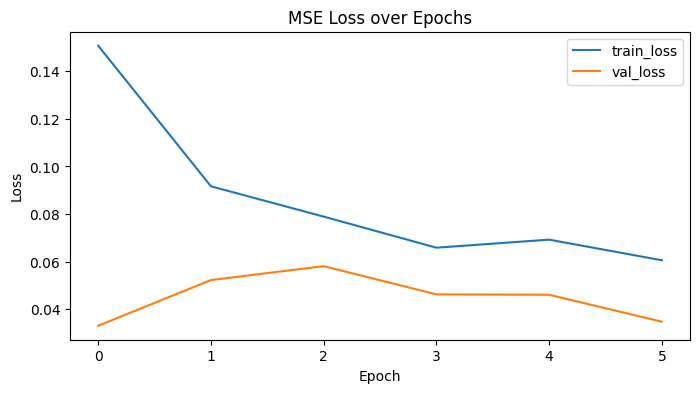

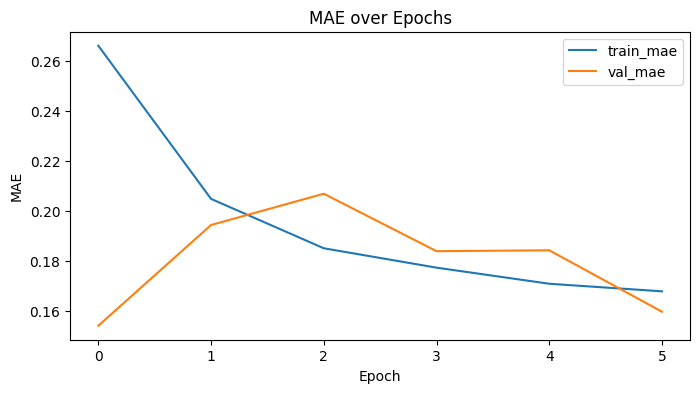

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt


df = df.rename(columns={'Price': 'Date'})
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)


for col in ['Open','High','Low','Close','Volume']:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df = df.dropna()

df['MA10'] = df['Close'].rolling(window=10).mean()
df = df.dropna().reset_index(drop=True)

feature_cols = ['Open','High','Low','Close','Volume','MA10']
scaler = StandardScaler()
df[feature_cols] = scaler.fit_transform(df[feature_cols])

window_size = 10
X, y = [], []
for i in range(window_size, len(df)):
    X.append(df[feature_cols].iloc[i-window_size:i].values)
    y.append(df['Close'].iloc[i])
X = np.array(X)   # (samples, window_size, features)
y = np.array(y)   # (samples,)

print("X.shape =", X.shape, "y.shape =", y.shape)

n = len(X)
train_end = int(n * 0.7)
val_end   = int(n * 0.85)

X_train, y_train = X[:train_end],   y[:train_end]
X_val,   y_val   = X[train_end:val_end], y[train_end:val_end]
X_test,  y_test  = X[val_end:],     y[val_end:]

print("Train/Val/Test sizes:", X_train.shape[0], X_val.shape[0], X_test.shape[0])

n_features = X.shape[2]
model = Sequential([
    tf.keras.Input(shape=(window_size, n_features)),
    LSTM(64, return_sequences=True),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dropout(0.2),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
mc = ModelCheckpoint('best_timeseries_model.keras', monitor='val_loss', save_best_only=True)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[es, mc],
    verbose=2
)

test_loss, test_mae = model.evaluate(X_test, y_test, verbose=0)
print(f"Test RMSE: {np.sqrt(test_loss):.4f}, Test MAE: {test_mae:.4f}")


plt.figure(figsize=(8,4))
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('MSE Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

plt.figure(figsize=(8,4))
plt.plot(history.history['mae'], label='train_mae')
plt.plot(history.history['val_mae'], label='val_mae')
plt.title('MAE over Epochs')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.show()


# Sentiment Vector Extraction and Embedding Representation of Financial News Texts (FinBERT / Word2Vec / LSTM)

In [ ]:
from google.colab import drive
import os
drive.mount('/content/drive')
os.chdir('/content/drive/MyDrive/242B/242B final project') # customize this line to your working directory

In [ ]:
!pip install numpy
!pip install transformers
!pip install gensim
!pip install keras


In [ ]:
import os
import pandas as pd

# working_dir = '/Users/liujiatong/Desktop/IND ENG 242B/project/1_fp' # On Laptop
# os.chdir(working_dir) # On Laptop
print("Current Working Directory:", os.getcwd())


file_name = 'apple_news_data.csv'
df = pd.read_csv(file_name)

object_columns = df.select_dtypes(include='object').columns
float_columns = df.select_dtypes(include='float64').columns

df[object_columns] = df[object_columns].fillna('')
df[float_columns] = df[float_columns].fillna(0.0)

df = df[['date', 'title', 'content']]

# Shortend length For time-saving testing 注
# df = df.iloc[:20].reset_index(drop=True)

df = df.iloc[::-1].reset_index(drop=True)
df['date'] = pd.to_datetime(df['date']).dt.date

df.info()
#df.head()
#df.tail(10)

In [ ]:
from sklearn.model_selection import train_test_split

aggregated = df.groupby('date').agg({
    'title': lambda x: ' [SEP] '.join(x),
    'content': lambda x: ' [SEP] '.join(x),
   # 'link': lambda x: ' + '.join(x),
   # 'symbols': lambda x: ' + '.join(x),
   # 'tags': lambda x: ' + '.join(x),
   # 'sentiment_polarity': 'sum',
   # 'sentiment_neg': 'sum',
   # 'sentiment_neu': 'sum',
   # 'sentiment_pos': 'sum'
}).reset_index()

aggregated = aggregated.sort_values(by='date').reset_index(drop=True)

aggregated.tail(10)
aggregated.info()

analysis = aggregated.copy()

In [ ]:
aggregated.tail(10)

pip install transformers

on apple silicon also install this to solve the issue:

conda install -c conda-forge liblapack

In [ ]:
from transformers import AutoTokenizer, AutoModel
import torch
import pandas as pd

# Load FinBERT model and tokenizer
model_name = 'yiyanghkust/finbert-tone'
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)
model.eval()

In [ ]:
"""def get_finbert_vector(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=64)
    with torch.no_grad():
        outputs = model(**inputs)
    cls_embedding = outputs.last_hidden_state[:, 0, :]  # CLS token
    return cls_embedding.squeeze().numpy()

# Apply to titles (can take time if 3,000 rows — consider batching)
analysis['sentiment_vector'] = analysis['title'].apply(get_finbert_vector)"""

import torch
import pandas as pd
import numpy as np
from transformers import AutoTokenizer, AutoModel
from tqdm import tqdm

analysis['title'] = analysis['title'].astype(str)

# Load FinBERT tokenizer and model
model_name = "yiyanghkust/finbert-tone"  # Or your preferred FinBERT variant
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
model.eval()

# Define a projection layer from 768 -> 128
# Since FinBERT generate a vector dimension of 768, to keep things consistent, uusing linear function to keep it in 128 for consistency
projection = torch.nn.Linear(768, 128).to(device) #remove for original 768
projection.eval() # remove for original 768

# Returns a single 128 dimension vector for each long text
def get_chunked_embedding(text):
    # Tokenize full text directly
    tokens = tokenizer(text, add_special_tokens=False)['input_ids']
    if not tokens:
        return np.zeros(128)

    # Split into 512-token chunks
    chunks = [tokens[i:i+512] for i in range(0, len(tokens), 512)]

    input_dict = tokenizer(
        tokenizer.batch_decode(chunks, skip_special_tokens=False),
        return_tensors="pt",
        padding="max_length",
        truncation=True,
        max_length=512
    ).to(device)

    with torch.no_grad():
        outputs = model(**input_dict)
        cls_batch = outputs.last_hidden_state[:, 0, :]  # shape: (num_chunks, 768)
        reduced = projection(cls_batch)  # shape: (num_chunks, 128)

    return reduced.cpu().numpy().mean(axis=0)  # Average across chunks

# Getting CLS embedding from batched texts
def get_batched_finbert_vectors(texts, batch_size=32, max_length=64):
    vectors = []
    for i in tqdm(range(0, len(texts), batch_size)):
        batch = texts[i:i + batch_size]

        inputs = tokenizer(batch, return_tensors="pt", truncation=True, padding=True, max_length=max_length)
        inputs = {k: v.to(device) for k, v in inputs.items()}

        with torch.no_grad():
            outputs = model(**inputs)
            cls_embeddings = outputs.last_hidden_state[:, 0, :]  # (B, 768) Remove if want keeping 768 original output
            reduced = projection(cls_embeddings)                 # (B, 128) Remove if want keeping 768 original output
            reduced = reduced.cpu().numpy()                      # Remove if want keeping 768 original output


        # cls_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy() # use for 768
        # vectors.extend(cls_embeddings) # use for 768

        vectors.extend(reduced) # Remove if want keeping 768 original output

    return np.array(vectors)


title_list = analysis['title'].astype(str).tolist()
sentiment_vector_FinBert_Title = get_batched_finbert_vectors(title_list, batch_size=32, max_length=256) #Note May change to 128 to save computing time
analysis['sentiment_vector_FinBert_Title'] = list(sentiment_vector_FinBert_Title)

tqdm.pandas() # for using progress_apply()
#content_list = analysis['content'].astype(str).tolist()
#sentiment_vector_FinBert_Content = get_batched_finbert_vectors(content_list, batch_size=16, max_length=512)
analysis['sentiment_vector_FinBert_Content'] = analysis['content'].progress_apply(get_chunked_embedding)


100%|██████████| 1574/1574 [23:49<00:00,  1.10it/s]


pip uninstall keras
pip install keras==2.11.0

In [ ]:
"""finbert_classifier = pipeline("text-classification", model=model_name, tokenizer=tokenizer, device=0 if torch.cuda.is_available() else -1)
analysis['sentiment_label'] = analysis['title'].apply(lambda x: finbert_classifier(x)[0]['label'])
analysis['sentiment_score'] = analysis['title'].apply(lambda x: finbert_classifier(x)[0]['score'])
"""

'finbert_classifier = pipeline("text-classification", model=model_name, tokenizer=tokenizer, device=0 if torch.cuda.is_available() else -1)\nanalysis[\'sentiment_label\'] = analysis[\'title\'].apply(lambda x: finbert_classifier(x)[0][\'label\'])\nanalysis[\'sentiment_score\'] = analysis[\'title\'].apply(lambda x: finbert_classifier(x)[0][\'score\'])\n'

In [ ]:
analysis.tail(5)

,date,title,content,sentiment_vector_FinBert_Title,sentiment_vector_FinBert_Content
1569,2024-11-23,Could Buying Apple Stock Today Set You Up for ...,Apple Intelligence is just the company's lates...,"[-0.017721567, 0.29930326, -0.028271852, -0.55...","[-0.24850386, 0.2442612, -0.055370227, -0.2124..."
1570,2024-11-24,How Tim Cook Cracked the Code on Working With ...,The election is leading to a return of persona...,"[-0.5890667, 0.4133732, -0.3678286, -0.9452182...","[-1.0069561, 0.48353556, -0.7533187, -0.131510..."
1571,2024-11-25,A Complete Guide to College Savings Accounts i...,A Complete Guide to College Savings Accounts i...,"[-0.7735809, -0.0202635, -0.52049255, -0.79906...","[-0.7735813, -0.0202635, -0.5204928, -0.799068..."
1572,2024-11-26,What Is the S&P 500 Index? [SEP] Dow Jones Ind...,What Is the S&P 500 Index? [SEP] Dow Jones Ind...,"[0.17557514, -0.5015, -0.0097572375, -1.017855...","[0.17557512, -0.5015, -0.009756671, -1.0178549..."
1573,2024-11-27,Berkshire Stock Hits Record Even as Company Re...,"Warren Buffett’s caution, his advancing age, a...","[-0.1221496, 0.29825148, -0.7800274, -0.939788...","[-0.51226157, 0.3833931, -0.5327885, -0.375454..."


Using Word2Vec to generate text embeddings by producing a vector summarization (embedding) of news

pip install gensim

In [ ]:
import gensim.downloader as api

# Load pretrained Word2Vec vectors (100-dim for speed, or 300-dim for quality)
word_vectors = api.load('word2vec-google-news-300')  # or 'glove-wiki-gigaword-100'

In [ ]:
import numpy as np

def to_vec(input_value):
    words = input_value.lower().split()
    vectors = [word_vectors[word] for word in words if word in word_vectors]
    if len(vectors) == 0:
        return np.zeros(word_vectors.vector_size)
    return np.mean(vectors, axis=0)


In [ ]:
import torch.nn as nn

analysis['embedding_vector_Word2Vec_Title'] = analysis['title'].astype(str).apply(to_vec)
analysis['embedding_vector_Word2Vec_Content'] = analysis['content'].astype(str).apply(to_vec)

title_matrix_300 = np.stack(analysis['embedding_vector_Word2Vec_Title'].values)
content_matrix_300 = np.stack(analysis['embedding_vector_Word2Vec_Content'].values)

projection = nn.Linear(300, 128)
projection.eval()  # inference mode

with torch.no_grad():
    title_tensor = torch.tensor(title_matrix_300, dtype=torch.float32)
    content_tensor = torch.tensor(content_matrix_300, dtype=torch.float32)

    title_vec_128 = projection(title_tensor).numpy()
    content_vec_128 = projection(content_tensor).numpy()

analysis['embedding_vector_Word2Vec_Title'] = list(title_vec_128)
analysis['embedding_vector_Word2Vec_Content'] = list(content_vec_128)

analysis.tail(5)

,date,title,content,sentiment_vector_FinBert_Title,sentiment_vector_FinBert_Content,embedding_vector_Word2Vec_Title,embedding_vector_Word2Vec_Content
1569,2024-11-23,Could Buying Apple Stock Today Set You Up for ...,Apple Intelligence is just the company's lates...,"[-0.017721567, 0.29930326, -0.028271852, -0.55...","[-0.24850386, 0.2442612, -0.055370227, -0.2124...","[0.0064862166, -0.02168461, 0.051490884, -0.00...","[-0.004681345, -0.034934986, 0.062362783, 0.00..."
1570,2024-11-24,How Tim Cook Cracked the Code on Working With ...,The election is leading to a return of persona...,"[-0.5890667, 0.4133732, -0.3678286, -0.9452182...","[-1.0069561, 0.48353556, -0.7533187, -0.131510...","[0.02586915, -0.020853879, 0.023784319, 0.0352...","[0.019033186, -0.004956767, 0.03125856, 0.0247..."
1571,2024-11-25,A Complete Guide to College Savings Accounts i...,A Complete Guide to College Savings Accounts i...,"[-0.7735809, -0.0202635, -0.52049255, -0.79906...","[-0.7735813, -0.0202635, -0.5204928, -0.799068...","[0.000955075, -0.022013322, 0.0623116, 0.01770...","[0.000955075, -0.022013322, 0.0623116, 0.01770..."
1572,2024-11-26,What Is the S&P 500 Index? [SEP] Dow Jones Ind...,What Is the S&P 500 Index? [SEP] Dow Jones Ind...,"[0.17557514, -0.5015, -0.0097572375, -1.017855...","[0.17557512, -0.5015, -0.009756671, -1.0178549...","[-0.0023475662, -0.025003593, 0.046119515, 0.0...","[-0.0023475662, -0.025003593, 0.046119515, 0.0..."
1573,2024-11-27,Berkshire Stock Hits Record Even as Company Re...,"Warren Buffett’s caution, his advancing age, a...","[-0.1221496, 0.29825148, -0.7800274, -0.939788...","[-0.51226157, 0.3833931, -0.5327885, -0.375454...","[-0.021273866, -0.040459365, -0.00015491713, 0...","[0.0003879238, -0.03706016, 0.05646489, -0.012..."


In [ ]:
# Option 2: Train Own Word2Vec (if lots of unlabeled titles). If want domain-specific vectors (such as financial jargon).

"""from gensim.models import Word2Vec

# Tokenize titles
titles = [title.lower().split() for title in df['title']]
model = Word2Vec(sentences=titles, vector_size=100, window=5, min_count=2, workers=4)

# Get the word vectors from the model
word_vectors = model.wv

# Averaging function
def avg_embedding_custom(title):
    words = title.lower().split()
    vectors = [word_vectors[word] for word in words if word in word_vectors]
    return np.mean(vectors, axis=0) if vectors else np.zeros(100)

df['embedding_vector'] = df['title'].apply(avg_embedding_custom)
"""

"from gensim.models import Word2Vec\n\n# Tokenize titles\ntitles = [title.lower().split() for title in df['title']]\nmodel = Word2Vec(sentences=titles, vector_size=100, window=5, min_count=2, workers=4)\n\n# Get the word vectors from the model\nword_vectors = model.wv\n\n# Averaging function\ndef avg_embedding_custom(title):\n    words = title.lower().split()\n    vectors = [word_vectors[word] for word in words if word in word_vectors]\n    return np.mean(vectors, axis=0) if vectors else np.zeros(100)\n\ndf['embedding_vector'] = df['title'].apply(avg_embedding_custom)\n"

Extracting feature vectors using RNN or LSTM: sentiment or feature vector extraction using LSTM in PyTorch:

Feeding each news title into an LSTM and extract a fixed-size vector (e.g., the final hidden state) to summarize its semantics

In [ ]:
# Preprocess the text (tokenize + encode)
import pandas as pd
from sklearn.model_selection import train_test_split
from torch.nn.utils.rnn import pad_sequence
from collections import Counter
import torch

# Titles Part
analysis['title'] = analysis['title'].astype(str)
titles = analysis['title'].tolist()

tokenized_titles = [title.lower().split() for title in titles]

word_counts_title = Counter(word for sentence in tokenized_titles for word in sentence)
vocab_titles = {word: idx+2 for idx, (word, _) in enumerate(word_counts_title.items())}
vocab_titles['<PAD>'] = 0
vocab_titles['<UNK>'] = 1

print(list(vocab_titles.items())[:10])
print(len(vocab_titles))

encoded_titles = [[vocab_titles.get(word, 1) for word in sentence] for sentence in tokenized_titles]

# Contents Part
analysis['content'] = analysis['content'].astype(str)
contents = analysis['content'].tolist()

tokenized_contents = [content.lower().split() for content in contents]

word_counts_contents = Counter(word for sentence in tokenized_contents for word in sentence)
vocab_contents = {word: idx+2 for idx, (word, _) in enumerate(word_counts_contents.items())}
vocab_contents['<PAD>'] = 0
vocab_contents['<UNK>'] = 1

print(list(vocab_contents.items())[0:10])
print(len(vocab_contents))

encoded_contents = [[vocab_contents.get(word, 1) for word in sentence] for sentence in tokenized_contents]

[('payment', 2), ('data', 3), ('systems', 4), ('announces', 5), ('apple', 6), ('pay', 7), ('support', 8), ('for', 9), ('akimbo', 10), ('prepaid', 11)]
24542
[('san', 2), ('antonio,', 3), ('feb.', 4), ('19,', 5), ('2016', 6), ('(globe', 7), ('newswire)', 8), ('--', 9), ('payment', 10), ('data', 11)]
292916


In [ ]:
from torch.utils.data import DataLoader, TensorDataset

# Titles
# Padding sequences
padded_titles = pad_sequence([torch.tensor(seq) for seq in encoded_titles],
                             batch_first=True, padding_value=0)

# Creating a dummy dataset (no labels, just inputs)
dataset_titles = TensorDataset(padded_titles)
loader_titles = DataLoader(dataset_titles, batch_size=32, shuffle=False)


# Contents
# Padding sequences
padded_contents = pad_sequence([torch.tensor(seq) for seq in encoded_contents],
                             batch_first=True, padding_value=0)

# Creating a dummy dataset (no labels, just inputs)
dataset_contents = TensorDataset(padded_contents)
loader_contents = DataLoader(dataset_contents, batch_size=32, shuffle=False)

In [ ]:
import torch.nn as nn

class LSTMEncoder(nn.Module):
    def __init__(self, vocab_size, embedding_dim=100, hidden_dim=128):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True)

    def forward(self, x):
        x = self.embedding(x)
        _, (h_n, _) = self.lstm(x)  # h_n shape: [1, B, H]
        return h_n.squeeze(0)       # Output: [B, H]

vocab_size_titles = len(vocab_titles)
model_titles = LSTMEncoder(vocab_size_titles)

vocab_size_contents = len(vocab_contents)
model_contents = LSTMEncoder(vocab_size_contents)

In [ ]:
# Extracting features from the LSTM (Titles)
model_titles.eval()
all_vectors_titles = []

with torch.no_grad():
    for batch in loader_titles:
        input_batch = batch[0]
        vectors = model_titles(input_batch)
        all_vectors_titles.extend(vectors.numpy())

analysis['feature_vector_LSTMEncoder_title'] = all_vectors_titles


# Extracting features from the LSTM (Contents)
model_contents.eval()
all_vectors_contents = []

with torch.no_grad():
    for batch in loader_contents:
        input_batch = batch[0]
        vectors = model_contents(input_batch)
        all_vectors_contents.extend(vectors.numpy())

analysis['feature_vector_LSTMEncoder_content'] = all_vectors_contents


In [ ]:
analysis.tail(5)

,date,title,content,sentiment_vector_FinBert_Title,sentiment_vector_FinBert_Content,embedding_vector_Word2Vec_Title,embedding_vector_Word2Vec_Content,feature_vector_LSTMEncoder_title,feature_vector_LSTMEncoder_content
1569,2024-11-23,Could Buying Apple Stock Today Set You Up for ...,Apple Intelligence is just the company's lates...,"[-0.017721567, 0.29930326, -0.028271852, -0.55...","[-0.24850386, 0.2442612, -0.055370227, -0.2124...","[0.0064862166, -0.02168461, 0.051490884, -0.00...","[-0.004681345, -0.034934986, 0.062362783, 0.00...","[-0.049244113, 0.0130969575, -0.0534134, 0.034...","[0.022004623, -0.024087094, -0.011549497, -0.0..."
1570,2024-11-24,How Tim Cook Cracked the Code on Working With ...,The election is leading to a return of persona...,"[-0.5890667, 0.4133732, -0.3678286, -0.9452182...","[-1.0069561, 0.48353556, -0.7533187, -0.131510...","[0.02586915, -0.020853879, 0.023784319, 0.0352...","[0.019033186, -0.004956767, 0.03125856, 0.0247...","[-0.049244113, 0.013096956, -0.0534134, 0.0345...","[0.022004623, -0.024087092, -0.0115495, -0.001..."
1571,2024-11-25,A Complete Guide to College Savings Accounts i...,A Complete Guide to College Savings Accounts i...,"[-0.7735809, -0.0202635, -0.52049255, -0.79906...","[-0.7735813, -0.0202635, -0.5204928, -0.799068...","[0.000955075, -0.022013322, 0.0623116, 0.01770...","[0.000955075, -0.022013322, 0.0623116, 0.01770...","[-0.04924411, 0.013096957, -0.053413395, 0.034...","[0.022004623, -0.02408709, -0.011549496, -0.00..."
1572,2024-11-26,What Is the S&P 500 Index? [SEP] Dow Jones Ind...,What Is the S&P 500 Index? [SEP] Dow Jones Ind...,"[0.17557514, -0.5015, -0.0097572375, -1.017855...","[0.17557512, -0.5015, -0.009756671, -1.0178549...","[-0.0023475662, -0.025003593, 0.046119515, 0.0...","[-0.0023475662, -0.025003593, 0.046119515, 0.0...","[-0.049244113, 0.013096955, -0.053413395, 0.03...","[0.022004623, -0.024087094, -0.011549498, -0.0..."
1573,2024-11-27,Berkshire Stock Hits Record Even as Company Re...,"Warren Buffett’s caution, his advancing age, a...","[-0.1221496, 0.29825148, -0.7800274, -0.939788...","[-0.51226157, 0.3833931, -0.5327885, -0.375454...","[-0.021273866, -0.040459365, -0.00015491713, 0...","[0.0003879238, -0.03706016, 0.05646489, -0.012...","[-0.04924411, 0.013096956, -0.053413395, 0.034...","[0.022004623, -0.024087092, -0.0115495, -0.001..."


In [ ]:
analysis.to_csv("vectors.csv", index=False)

# FinBERT classifier outputs three types of probabilities (neg, neu, pos)

In [ ]:
import pandas as pd

In [ ]:
# siqing's working directory
from google.colab import drive
import os
drive.mount('/content/drive')
work_pth = '/content/drive/MyDrive/242B/242B final project'
os.chdir(work_pth) # customize this line to your working directory

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
news_data = pd.read_csv('apple_news_data.csv')

In [ ]:
news_data

,date,title,content,link,symbols,tags,sentiment_polarity,sentiment_neg,sentiment_neu,sentiment_pos
0,2024-11-27T16:39:00+00:00,Berkshire Stock Hits Record Even as Company Re...,"Warren Buffett’s caution, his advancing age, a...",https://finance.yahoo.com/m/f5df3aa4-364b-31d6...,"0R2V.IL, AAPL.BA, AAPL.MX, AAPL.NEO, AAPL.SN, ...",NaN,0.000,0.000,1.000,0.000
1,2024-11-26T00:00:00+00:00,What Is a Stock Market Index?,What Is a Stock Market Index?,https://www.fool.com/investing/stock-market/in...,"AAPL.US, AMZN.US, MSFT.US",NaN,0.000,0.000,1.000,0.000
2,2024-11-26T00:00:00+00:00,"Could Investing $1,000 in Apple Make You a Mil...","Could Investing $1,000 in Apple Make You a Mil...",https://www.fool.com/investing/2024/11/26/coul...,AAPL.US,NaN,0.000,0.000,1.000,0.000
3,2024-11-26T00:00:00+00:00,Dow Jones Industrial Average,Dow Jones Industrial Average,https://www.fool.com/investing/stock-market/in...,"AAPL.US, AMGN.US, AMZN.US, CSCO.US, GOOG.US, G...",NaN,0.000,0.000,1.000,0.000
4,2024-11-26T00:00:00+00:00,What Is the S&P 500 Index?,What Is the S&P 500 Index?,https://www.fool.com/investing/stock-market/in...,"AAPL.US, AMZN.US, GOOG.US, GOOGL.US, META.US, ...",NaN,0.000,0.000,1.000,0.000
...,...,...,...,...,...,...,...,...,...,...
29747,2018-01-31T12:55:00+00:00,Investor Expectations to Drive Momentum within...,"NEW YORK, Jan. 31, 2018 (GLOBE NEWSWIRE) -- ...",https://www.globenewswire.com/news-release/201...,"AAPL.US, AVHI.US, FARM.US, GM.US, SGRY.US",FUNDAMENTAL MARKETS,0.995,0.009,0.937,0.054
29748,2017-11-30T14:27:00+00:00,"BioTelemetry, Inc. Enters Agreement to Provide...","MALVERN, Pa., Nov. 30, 2017 (GLOBE NEWSWIRE)...",https://www.globenewswire.com/news-release/201...,"AAPL.US, BEAT.US","BIOTELEMETRY, INC, NASDAQ:BEAT",0.989,0.021,0.804,0.174
29749,2017-11-27T13:00:00+00:00,"Factors of Influence in 2018, Key Indicators a...","NEW YORK, Nov. 27, 2017 (GLOBE NEWSWIRE) -- ...",https://www.globenewswire.com/news-release/201...,"AAPL.US, CSCO.US, GD.US, HPE.US, NVDA.US, S.US",FUNDAMENTAL MARKETS,0.997,0.008,0.926,0.065
29750,2017-10-05T15:58:00+00:00,New Research: Key Drivers of Growth for Micros...,"NEW YORK, Oct. 05, 2017 (GLOBE NEWSWIRE) -- ...",https://www.globenewswire.com/news-release/201...,"AAPL.US, AMZN.US, INTC.US, MSFT.US, QCOM.US, T...",FUNDAMENTAL MARKETS,0.997,0.008,0.925,0.067


In [ ]:
useful_columns = ['date', 'title', 'content']
df = news_data[useful_columns]
df['text'] = df['title'] + ' ' + df['content']
df = df.drop(columns=['title', 'content'])
df

<ipython-input-42-67100bb6ed8c>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['text'] = df['title'] + ' ' + df['content']


,date,text
0,2024-11-27T16:39:00+00:00,Berkshire Stock Hits Record Even as Company Re...
1,2024-11-26T00:00:00+00:00,What Is a Stock Market Index? What Is a Stock ...
2,2024-11-26T00:00:00+00:00,"Could Investing $1,000 in Apple Make You a Mil..."
3,2024-11-26T00:00:00+00:00,Dow Jones Industrial Average Dow Jones Industr...
4,2024-11-26T00:00:00+00:00,What Is the S&P 500 Index? What Is the S&P 500...
...,...,...
29747,2018-01-31T12:55:00+00:00,Investor Expectations to Drive Momentum within...
29748,2017-11-30T14:27:00+00:00,"BioTelemetry, Inc. Enters Agreement to Provide..."
29749,2017-11-27T13:00:00+00:00,"Factors of Influence in 2018, Key Indicators a..."
29750,2017-10-05T15:58:00+00:00,New Research: Key Drivers of Growth for Micros...


# Data Split

In [ ]:
df = df.sort_values('date')

In [ ]:
df['date'] = pd.to_datetime(df['date']).dt.date

In [ ]:
# Group by date and concatenate texts
daily_combined = df.groupby('date')['text'].apply(lambda x: ' '.join(x)).reset_index()

In [ ]:
n = len(daily_combined)
train_end = int(n * 0.7)
val_end = int(n * 0.85)

train_data = daily_combined.iloc[:train_end]
val_data   = daily_combined.iloc[train_end:val_end]
test_data  = daily_combined.iloc[val_end:]

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
import pandas as pd
from tqdm import tqdm

# 1. Load tokenizer and model
tokenizer = AutoTokenizer.from_pretrained("yiyanghkust/finbert-tone")
model = AutoModelForSequenceClassification.from_pretrained("yiyanghkust/finbert-tone")
model.eval()  # set model to evaluation mode



device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
model.to(device)

def get_sentiment_probs_batch_gpu(texts, batch_size=32):
    all_probs = []
    for i in tqdm(range(0, len(texts), batch_size), desc="Processing Batches"):
        batch_texts = texts[i:i+batch_size]
        inputs = tokenizer(batch_texts, return_tensors="pt", truncation=True, padding=True, max_length=100)

        # Move tensors to GPU
        inputs = {key: value.to(device) for key, value in inputs.items()}

        with torch.no_grad():
            outputs = model(**inputs)
        probs = torch.nn.functional.softmax(outputs.logits, dim=-1)
        all_probs.append(probs.squeeze().tolist())

    return [item for sublist in all_probs for item in sublist]

# Apply to the DataFrame
daily_combined[['neg', 'neu', 'pos']] = pd.DataFrame(get_sentiment_probs_batch_gpu(daily_combined['text'].tolist()))


cpu


Processing Batches: 100%|██████████| 50/50 [09:52<00:00, 11.85s/it]


In [ ]:
daily_combined.to_csv('daily_combined.csv')

In [ ]:
# !pip install --upgrade torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
# !pip install --upgrade transformers

In [ ]:
daily_combined = pd.read_csv('daily_combined.csv')
daily_combined

,Unnamed: 0,date,text,neg,neu,pos
0,0,2016-02-19,Payment Data Systems Announces Apple Pay Suppo...,0.006525,9.934698e-01,5.569048e-06
1,1,2017-10-05,New Research: Key Drivers of Growth for Micros...,0.999333,6.645875e-04,2.352576e-06
2,2,2017-11-27,"Factors of Influence in 2018, Key Indicators a...",0.999917,8.108789e-05,1.589962e-06
3,3,2017-11-30,"BioTelemetry, Inc. Enters Agreement to Provide...",0.991337,8.497693e-03,1.649333e-04
4,4,2018-01-31,Investor Expectations to Drive Momentum within...,0.968747,3.124903e-02,3.704875e-06
...,...,...,...,...,...,...
1569,1569,2024-11-23,Could Buying Apple Stock Today Set You Up for ...,0.994446,3.185394e-03,2.368481e-03
1570,1570,2024-11-24,How Tim Cook Cracked the Code on Working With ...,0.999603,2.062642e-04,1.903490e-04
1571,1571,2024-11-25,A Complete Guide to College Savings Accounts i...,0.999999,1.047195e-06,3.534029e-07
1572,1572,2024-11-26,What Is the S&P 500 Index? What Is the S&P 500...,1.000000,5.424092e-08,4.477245e-07


The goal of the project is to predict stock prices or ups and downs through multimodal information (time series + news sentiment). We tried two textual sentiment feature extraction approaches:

FinBERT/Word2Vec/LSTM vector embedding approach: daily news is converted into dense semantic vectors (e.g., 128-dimensional) and used as deep features;

FinBERT classifier output sentiment probability approach: directly extract the probability values (neg/neu/pos) of negative, neutral, and positive in daily reports.

Final choice: using FinBERT sentiment probability
We chose to use FinBERT classification probabilities (neg/neu/pos) with time series feature splicing as the final solution for the following reasons:

More suitable for structured feature fusion with OHLCV time series data;

Can be used directly for classification tasks (predicting stock ups and downs) without the need for complex model structure;

Sentiment probabilities have clear meanings, contributing to model interpretability;

It is more efficient in actual training and avoids the training burden of high-dimensional vectors.


# Baseline Model – Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score

# Baseline Logistic Regression
baseline_model = LogisticRegression(max_iter=500, class_weight='balanced', random_state=42)
baseline_model.fit(X_train, y_train)

# Evaluate on test set
y_pred_baseline = baseline_model.predict(X_test)
y_prob_baseline = baseline_model.predict_proba(X_test)[:, 1]

baseline_accuracy = accuracy_score(y_test, y_pred_baseline)
baseline_auc = roc_auc_score(y_test, y_prob_baseline)
baseline_report = classification_report(y_test, y_pred_baseline, digits=4)

print("=== Baseline Model: Logistic Regression ===")
print(f"Accuracy : {baseline_accuracy:.4f}")
print(f"ROC-AUC  : {baseline_auc:.4f}")
print("Classification Report:")
print(baseline_report)

=== Baseline Model: Logistic Regression ===
Accuracy : 0.3865
ROC-AUC  : 0.5613
Classification Report:
              precision    recall  f1-score   support

           0     0.3865    1.0000    0.5575        63
           1     0.0000    0.0000    0.0000       100

    accuracy                         0.3865       163
   macro avg     0.1933    0.5000    0.2788       163
weighted avg     0.1494    0.3865    0.2155       163



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# MLPClassifier (Multilayer Perceptron Machine)

Input features: technical indicators (Open, High, Low, etc.) + FinBERT sentiment probabilities (neg/neu/pos)

Task Objective: Predict whether the stock price will increase the next day (1 means increase, 0 means no increase)

In [ ]:
import pandas as pd

stock_data = pd.read_csv('/content/drive/MyDrive/242B/242B final project/AAPL_stockPrice.csv')
print(stock_data.head())
cols = ['Date', 'Close', 'High', 'Low', 'Open', 'Volume']
stock_data = pd.read_csv(
    '/content/drive/MyDrive/242B/242B final project/AAPL_stockPrice.csv',
    skiprows=2,
    names=cols
)

        Price              Close               High                Low  \
0      Ticker               AAPL               AAPL               AAPL   
1        Date                NaN                NaN                NaN   
2  2020-01-02  72.71607208251953  72.77659819422657  71.46681225027338   
3  2020-01-03   72.0091323852539  72.77176000550182  71.78397699623217   
4  2020-01-06  72.58290100097656  72.62163859417052  70.87606782262263   

                Open     Volume  
0               AAPL       AAPL  
1                NaN        NaN  
2  71.72101896406637  135480400  
3   71.9413434276417  146322800  
4  71.12785848416316  118387200  


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, accuracy_score

# Step 1: Load and clean stock data
cols = ['Date', 'Close', 'High', 'Low', 'Open', 'Volume']
stock_data = pd.read_csv(
    '/content/drive/MyDrive/242B/242B final project/AAPL_stockPrice.csv',
    skiprows=2,
    names=cols
)

# Convert the Date column and drop invalid rows
stock_data['Date'] = pd.to_datetime(stock_data['Date'], errors='coerce').dt.date
stock_data = stock_data.dropna().reset_index(drop=True)

# Step 2: Load and prepare sentiment data
sentiment_data = pd.read_csv('/content/drive/MyDrive/242B/242B final project/daily_combined.csv')
sentiment_data['date'] = pd.to_datetime(sentiment_data['date'], errors='coerce').dt.date
sentiment_data = sentiment_data.dropna(subset=['date'])

# Step 3: Merge by date
merged = pd.merge(stock_data, sentiment_data, left_on='Date', right_on='date', how='inner')

# Step 4: Add 10-day moving average and label
merged['MA10'] = merged['Close'].rolling(window=10).mean()
merged['Next_Close'] = merged['Close'].shift(-1)
merged['Label'] = (merged['Next_Close'] > merged['Close']).astype(int)
merged = merged.dropna().reset_index(drop=True)

# Step 5: Standardize time series features
feature_cols = ['Open', 'High', 'Low', 'Close', 'Volume', 'MA10']
scaler = StandardScaler()
merged[feature_cols] = scaler.fit_transform(merged[feature_cols])

# Step 6: Combine with sentiment probabilities
sentiment_cols = ['neg', 'neu', 'pos']
financial_features = merged[feature_cols].values
sentiment_features = merged[sentiment_cols].values
combined_features = np.concatenate([financial_features, sentiment_features], axis=1)

# Step 7: Train/val/test split
labels = merged['Label'].values
X_train, X_temp, y_train, y_temp = train_test_split(combined_features, labels, test_size=0.3, shuffle=False)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, shuffle=False)

# Step 8: Train MLP classifier
mlp = MLPClassifier(hidden_layer_sizes=(128, 64), activation='relu', max_iter=500, random_state=42)
mlp.fit(X_train, y_train)

<ipython-input-61-8f2e3c6eecc8>:17: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  stock_data['Date'] = pd.to_datetime(stock_data['Date'], errors='coerce').dt.date
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=500, random_state=42)

In [ ]:
val_pred = mlp.predict(X_val)
val_accuracy = accuracy_score(y_val, val_pred)
print(f"Validation Accuracy: {val_accuracy:.4f}")

Validation Accuracy: 0.5370


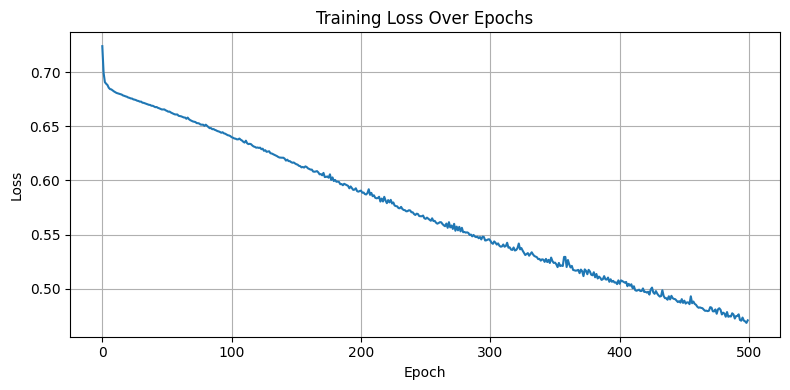

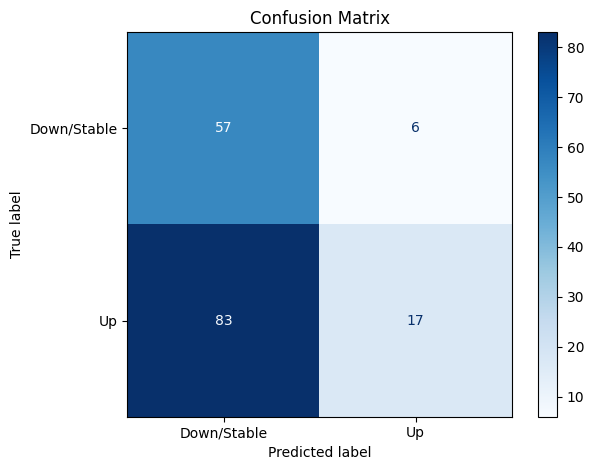

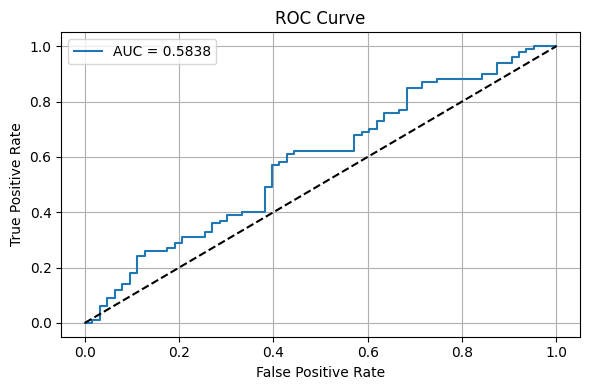

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve

# Plot training loss
plt.figure(figsize=(8, 4))
plt.plot(mlp.loss_curve_)
plt.title("Training Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.tight_layout()
plt.show()

# Evaluate on test set
y_pred = mlp.predict(X_test)
y_prob = mlp.predict_proba(X_test)[:, 1]
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, digits=4)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Down/Stable", "Up"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.grid(False)
plt.tight_layout()
plt.show()

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
def format_classification_markdown(report_str, accuracy, roc_auc):
    lines = report_str.strip().split("\n")
    class_lines = [line for line in lines if line.strip() and line.strip()[0].isdigit()]
    avg_lines = [line for line in lines if "avg" in line]

    def format_row(label, row_data):
        values = [f"{float(x):.4f}" for x in row_data]
        return f"| **{label}** | " + " | ".join(values) + " |"

    output = f"""### Model Evaluation Summary

**Accuracy:** `{accuracy:.4f}`
**ROC-AUC:** `{roc_auc:.4f}`

#### Classification Report

| Class | Precision | Recall | F1-Score | Support |
|-------|-----------|--------|----------|---------|"""

    for line in class_lines:
        parts = line.split()
        label = parts[0]
        rest = parts[1:]
        output += "\n" + format_row(label, rest)

    output += "\n\n| Metric        | Precision | Recall | F1-Score | Support |\n|---------------|-----------|--------|----------|---------|"
    for line in avg_lines:
        parts = line.split()
        label = " ".join(parts[:-4])
        rest = parts[-4:]
        output += "\n" + format_row(label, rest)

    return output


formatted_markdown = format_classification_markdown(report, accuracy, roc_auc)
print(formatted_markdown)

### Model Evaluation Summary

**Accuracy:** `0.4540`  
**ROC-AUC:** `0.5838`  

#### Classification Report

| Class | Precision | Recall | F1-Score | Support |
|-------|-----------|--------|----------|---------|
| **0** | 0.4071 | 0.9048 | 0.5616 | 63.0000 |
| **1** | 0.7391 | 0.1700 | 0.2764 | 100.0000 |

| Metric        | Precision | Recall | F1-Score | Support |
|---------------|-----------|--------|----------|---------|
| **macro avg** | 0.5731 | 0.5374 | 0.4190 | 163.0000 |
| **weighted avg** | 0.6108 | 0.4540 | 0.3866 | 163.0000 |
